In [1]:
import torch,os,math,gzip, pickle
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
from pathlib import Path

from torch import tensor
import torchvision as tv
import torchvision.transforms.functional as tvf
from torchvision import io
from torch.utils.cpp_extension import load_inline

In [2]:
img = io.read_image('puppy.jpg')
print(img.shape)
img[:2,:3,:4]

torch.Size([3, 1330, 1920])


tensor([[[225, 225, 225, 225],
         [225, 225, 225, 225],
         [225, 225, 225, 225]],

        [[228, 228, 228, 228],
         [228, 228, 228, 228],
         [228, 228, 228, 228]]], dtype=torch.uint8)

In [3]:
def show_img(x, figsize=(4,3), **kwargs):
    plt.figure(figsize=figsize)
    plt.axis('off')
    if len(x.shape)==3: x = x.permute(1,2,0)  # CHW -> HWC
    plt.imshow(x.cpu(), **kwargs)

In [4]:
img2 = tvf.resize(img, 150, antialias=True)
ch,h,w = img2.shape
ch,h,w,h*w

(3, 150, 216, 32400)

In [5]:
img2 = tvf.resize(img, 150, antialias=True)
ch,h,w = img2.shape
ch,h,w,h*w

(3, 150, 216, 32400)

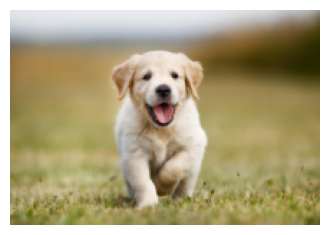

In [6]:
show_img(img2)

In [7]:
def rgb2grey_py(x):
    c,h,w = x.shape
    n = h*w
    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)
    for i in range(n): res[i] = 0.2989*x[i] + 0.5870*x[i+n] + 0.1140*x[i+2*n]
    return res.view(h,w)

In [15]:
%%time
img_g = rgb2grey_py(img2)

CPU times: total: 1.23 s
Wall time: 1.28 s


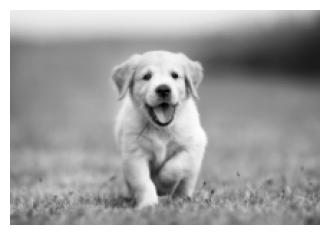

In [16]:
show_img(img_g, cmap='gray')

In [17]:
#%pip install wurlitzer 

In [21]:
os.environ['CUDA_LAUNCH_BLOCKING']='1'

In [23]:
#%load_ext wurlitzer
#from wurlitzer import sys_pipes
#import IPython.utils.io as ipio
#import sys

In [25]:
def load_cuda(cuda_src, cpp_src, funcs, opt=False, verbose=False):
    return load_inline(cuda_sources=[cuda_src], cpp_sources=[cpp_src], functions=funcs,
                       extra_cuda_cflags=["-O2"] if opt else [], verbose=verbose, name="inline_ext")

In [27]:
cuda_begin = r'''
#include <torch/extension.h>
#include <stdio.h>
#include <c10/cuda/CUDAException.h>

#define CHECK_CUDA(x) TORCH_CHECK(x.device().is_cuda(), #x " must be a CUDA tensor")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)

inline unsigned int cdiv(unsigned int a, unsigned int b) { return (a + b - 1) / b;}
'''

In [29]:
cuda_src = cuda_begin + r'''
__global__ void rgb_to_grayscale_kernel(unsigned char* x, unsigned char* out, int n) {
    int i = blockIdx.x*blockDim.x + threadIdx.x;
    if (i<n) out[i] = 0.2989*x[i] + 0.5870*x[i+n] + 0.1140*x[i+2*n];
}

torch::Tensor rgb_to_grayscale(torch::Tensor input) {
    CHECK_INPUT(input);
    int h = input.size(1);
    int w = input.size(2);
    printf("h*w: %d*%d\n", h, w);
    auto output = torch::empty({h,w}, input.options());
    int threads = 256;
    rgb_to_grayscale_kernel<<<cdiv(w*h,threads), threads>>>(
        input.data_ptr<unsigned char>(), output.data_ptr<unsigned char>(), w*h);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return output;
}'''

In [31]:
cpp_src = "torch::Tensor rgb_to_grayscale(torch::Tensor input);"

In [33]:
from torch.utils.cpp_extension import load_inline

In [35]:
#with sys_pipes():
#with ipio.redirect_stdout(sys.stdout),ipio.redirect_stderr(sys.stderr):
module = load_cuda(cuda_src, cpp_src, ['rgb_to_grayscale'], verbose=True)

Using C:\Users\k_wan\AppData\Local\torch_extensions\torch_extensions\Cache\py310_cu118 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file C:\Users\k_wan\AppData\Local\torch_extensions\torch_extensions\Cache\py310_cu118\inline_ext\build.ninja...
Building extension module inline_ext...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)
Loading extension module inline_ext...


In [37]:
[o for o in dir(module) if o[0]!='_']

['rgb_to_grayscale']

In [47]:
imgc = img.contiguous().cuda()

In [49]:
%%time
res = module.rgb_to_grayscale(imgc).cpu()
h,w = res.shape
h,w,h*w

CPU times: total: 0 ns
Wall time: 19.7 ms


(1330, 1920, 2553600)

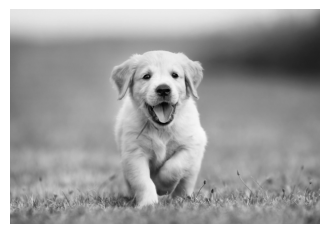

In [51]:
show_img(res, cmap='gray')

NameError: name 'cuda' is not defined